In [1]:
import sys
sys.path.append('C:/Users/ryansenne/PycharmProjects/dCA1_Paper')

import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.stats import iqr
from matplotlib.cm import get_cmap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

## Post hoc analysis of hierarchical bayesian model of Figure 2

In [ ]:
df = pd.read_csv(r"C:\Users\ryansenne\Desktop\Dill\astrocyte_shot_Gaussian_noise3_all.csv")
df = df[df['animal'] != 'F8']

names = np.unique(df['animal'])

df_2 = pd.read_csv(r"C:\Users\ryansenne\Desktop\Dill\astrocyte_NEWhab_Gaussian_noise3_all(1).csv")
df_2 = df_2[~df_2['animal'].isin(names)]

# combine the dfs
df = pd.concat([df, df_2], ignore_index=True)

,Unnamed: 0,pred_a1,pred_a0,pred_mu,pred_sigma,pred_mu_sigma,variance,mean_peak,mu_1,mu_2,mu_3,mu_4,CellID,animal,mu_5,mu_6,mu_7,mu_8
0,1,0.0,0.0,2.6,0.5,0.5,0.512348,2.675,2.6,2.9,2.0,3.2,1,F3.,NaN,NaN,NaN,NaN
1,10,0.0,0.0,2.3,0.8,0.6,0.493288,2.350,2.3,2.3,1.8,3.0,10,F3.,NaN,NaN,NaN,NaN
2,100,0.0,0.0,13.0,8.1,0.8,2.459505,5.325,7.1,4.2,7.6,2.4,100,F3.,NaN,NaN,NaN,NaN
3,1000,0.1,0.0,3.2,0.8,0.3,0.287228,3.175,3.1,3.0,3.0,3.6,1000,F9.,NaN,NaN,NaN,NaN
4,1001,0.1,0.0,3.7,1.3,0.2,0.330404,3.625,3.2,3.7,3.6,4.0,1001,F9.,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2702,154,0.1,0.0,9.6,5.6,7.6,6.788225,11.300,6.5,16.1,NaN,NaN,154,M10,NaN,NaN,NaN,NaN
2703,155,0.0,0.0,35.0,0.2,4.4,3.394113,37.800,35.4,40.2,NaN,NaN,155,M10,NaN,NaN,NaN,NaN
2704,156,0.1,0.0,0.0,1.9,13.3,24.960869,18.350,0.7,36.0,NaN,NaN,156,M10,NaN,NaN,NaN,NaN
2705,157,0.0,0.0,3.9,4.8,0.8,0.282843,6.200,6.0,6.4,NaN,NaN,157,M10,NaN,NaN,NaN,NaN


## Density Plot of Peak Times

## Linear Mixed Effects Model

In [ ]:
# # RI+RS
m_rs = smf.mixedlm("pred_sigma ~ pred_mu", data=df, groups=df["animal"], re_formula="~pred_mu")
res_rs_ml = m_rs.fit(reml=False, method="lbfgs")

LR stat = -inf, df = 2, p = 1


In [28]:
res_rs_ml.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:               MixedLM  Dependent Variable:  pred_sigma
No. Observations:    2707     Method:              ML        
No. Groups:          14       Scale:               3.8340    
Min. group size:     52       Log-Likelihood:      -5705.3153
Max. group size:     309      Converged:           Yes       
Mean group size:     193.4                                   
-------------------------------------------------------------
                    Coef.  Std.Err.   z   P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept            0.041    0.401 0.102 0.919 -0.745  0.826
pred_mu              0.300    0.049 6.165 0.000  0.205  0.395
Group Var            2.164    0.451                          
Group x pred_mu Cov -0.227    0.048                          
pred_mu Var          0.030    0.006                          
=============================================================

"""

C:\Users\ryansenne\AppData\Local\Temp\ipykernel_12796\2987064579.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap("tab20")


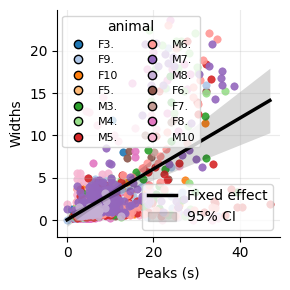

In [29]:
# --- Choose which fitted model to visualize ---
# model = res_ri_ml
model = res_rs_ml

# === 0) Helpers to make naming robust ===
fe = model.fe_params
fe_names = list(fe.index)

# Fixed-effect names
intercept_name = "Intercept" if "Intercept" in fe_names else ("const" if "const" in fe_names else None)
slope_name = "pred_mu"  # as used in your formula

if intercept_name is None:
    raise ValueError("Could not find Intercept/const in fixed effects.")

beta0 = float(fe[intercept_name])
beta1 = float(fe[slope_name])

# Covariance of FIXED effects only (for CI around the black line)
cov_all = model.cov_params()
cov_fe = cov_all.loc[fe.index, fe.index]
col_order = [intercept_name, slope_name]
cov_mat = cov_fe.loc[col_order, col_order].values

# === 1) Scatter each animal in its own color ===
fig, ax = plt.subplots(figsize=(3, 3))

animals = list(df["animal"].unique())
cmap = get_cmap("tab20")
color_map = {a: cmap(i % 20) for i, a in enumerate(animals)}

for a, g in df.groupby("animal"):
    ax.scatter(g["pred_mu"], g["pred_sigma"], label=str(a), alpha=0.9, s=28, color=color_map[a], linewidths=0.5)

ax.set_xlabel("Peaks (s)")
ax.set_ylabel("Widths")

# === 2) Population (fixed-effect) line + 95% CI ===
xgrid = np.linspace(df["pred_mu"].min(), df["pred_mu"].max(), 200)
X = np.column_stack([np.ones_like(xgrid), xgrid])

beta_vec = np.array([beta0, beta1])
yhat = X @ beta_vec
var = np.einsum("ij,jk,ik->i", X, cov_mat, X)  # diag(X Σ Xᵀ)
se = np.sqrt(var)
z = 1.96
lo, hi = yhat - z * se, yhat + z * se

ax.plot(xgrid, yhat, color="black", lw=2.5, label="Fixed effect")
ax.fill_between(xgrid, lo, hi, color="black", alpha=0.15, linewidth=0, label="95% CI")

# === 3) Subject-specific lines (fixed + random effects) ===
# Each group's random effects are in model.random_effects[group]
# Names usually include 'Intercept' (or sometimes only one unnamed column for RI-only) and 'pred_mu' for RS.
re_dict = model.random_effects  # {group: pandas Series or array-like}

def extract_group_effects(re_series):
    """Return (u0, u1) for intercept and slope random effects for a group.
       Robust to RI-only models and naming differences.
    """
    # Convert to dict-like with names if needed
    if hasattr(re_series, "index"):
        names = list(re_series.index)
        # Intercept
        if "Intercept" in names:
            u0 = float(re_series["Intercept"])
        elif "const" in names:
            u0 = float(re_series["const"])
        elif len(re_series) == 1:
            # RI-only often returns a single entry
            u0 = float(re_series.iloc[0])
        else:
            # Fallback
            u0 = 0.0
        # Slope
        u1 = float(re_series["pred_mu"]) if "pred_mu" in names else 0.0
    else:
        # If array-like without names: assume RI-only
        arr = np.asarray(re_series).ravel()
        u0 = float(arr[0]) if arr.size >= 1 else 0.0
        u1 = float(arr[1]) if arr.size >= 2 else 0.0
    return u0, u1

# # Draw each group's line in its color (light, thin) across its x-range to reduce clutter
# for a, g in df.groupby("animal"):
#     u0, u1 = extract_group_effects(re_dict[a])
#     b0_g = beta0 + u0
#     b1_g = beta1 + u1

#     # Optional: restrict line to that animal's observed x-range
#     xg = np.linspace(g["pred_mu"].min(), g["pred_mu"].max(), 50)
#     yg = b0_g + b1_g * xg

#     ax.plot(xg, yg, color=color_map[a], lw=1.8, alpha=0.8)

# === 4) Styling ===
# Put animal legend in one place; add custom handles for FE line + CI
animal_handles = [Line2D([0], [0], marker='o', color='none', markerfacecolor=color_map[a], label=str(a), markersize=6)
                  for a in animals]

fe_handles = [
    Line2D([0], [0], color='black', lw=2.5, label='Fixed effect'),
    Patch(facecolor='black', alpha=0.15, label='95% CI')
]

first_legend = ax.legend(handles=animal_handles, title="animal", fontsize=8, ncol=2, loc="upper left", frameon=True)
ax.add_artist(first_legend)
ax.legend(handles=fe_handles, loc="lower right", frameon=True)
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.savefig("lmem.svg")


# Make histogram of all peak times

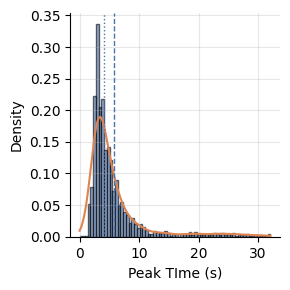

In [26]:
x = df["pred_mu"].dropna().to_numpy()

# Focus on the bulk trim extreme tail for visualization
p99 = np.percentile(x, 99)
x_view = x[x <= p99]

# Freedman–Diaconis bin width
bw = 2 * iqr(x_view) / (len(x_view) ** (1/3))
nbins = int(np.ceil((x_view.max() - x_view.min()) / bw)) if bw > 0 else "auto"

fig, ax = plt.subplots(figsize=(3,3))
ax.hist(x_view, bins=nbins, density=True, alpha=0.6, edgecolor="black")

# KDE (matplotlib only)
kde = gaussian_kde(x_view)  # Scott’s rule by default
xs = np.linspace(x_view.min(), x_view.max(), 512)
ax.plot(xs, kde(xs))

# Summary lines
ax.axvline(x_view.mean(), linestyle="--", linewidth=1)
ax.axvline(np.median(x_view), linestyle=":", linewidth=1)

ax.set_xlabel("Peak TIme (s)")
ax.set_ylabel("Density")
ax.grid(True, alpha=0.3)
fig.tight_layout()

plt.savefig("kde_plot.svg")

In [30]:
x = df["pred_mu"].dropna().to_numpy()

pp_25 = np.percentile(x, 25)
pp_50 = np.percentile(x, 50)
pp_75 = np.percentile(x, 75)
pp_90 = np.percentile(x, 90)

In [31]:
pp_25

3.0

In [32]:
pp_50

4.1

In [33]:
pp_75

6.4

In [34]:
pp_90

12.1